In [2]:
from pathlib import Path
import pandas as pd
import xarray as xr
import tempfile
import tarfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import contextily as cx
from pyproj import Transformer
from tqdm.auto import tqdm

c:\Users\janav\Documents\projects\spatio-temporal-xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Unzip and load .zarr cube

In [3]:
tar_path = "area_1.tar"
tmp = tempfile.TemporaryDirectory()
extract_dir = Path(tmp.name)

with tarfile.open(tar_path, "r:*") as tar:
    tar.extractall(extract_dir)

zarr_path = next(extract_dir.rglob("*.zarr"))
chla = xr.open_zarr(zarr_path, consolidated=True)

### Drop dates before 20.09.1997

In [4]:
HARD_START_DATE = pd.Timestamp("1997-09-20")
chla = chla.sel(time=slice(HARD_START_DATE, None))

### Find missing periods

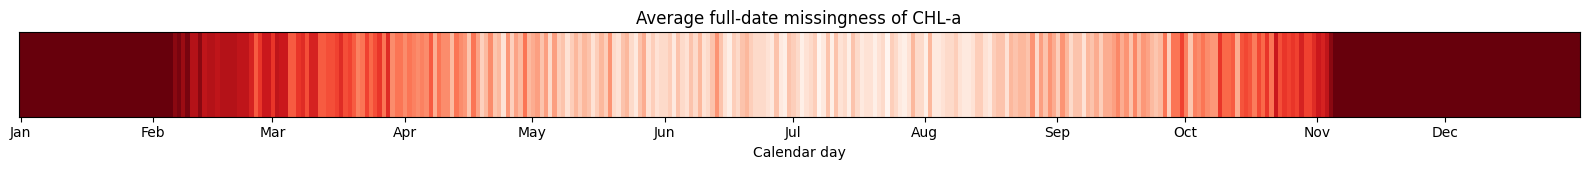

In [5]:
missing = chla["CHL"].isnull().all(dim=("cell")).values
dates = pd.to_datetime(chla["time"].values)
years = np.sort(dates.year.unique())
yearly = np.full((len(years), 366), np.nan)

for i, year in enumerate(years):
        d = dates[dates.year == year]
        yearly[i, d.dayofyear - 1] = missing[dates.year == year]

avg = np.nanmean(yearly, axis=0)

plt.figure(figsize=(16, 1.8))
plt.imshow([avg], cmap="Reds", aspect="auto", vmin=0, vmax=1)

months = pd.date_range("2023-01-01", "2023-12-01", freq="MS")
plt.xticks(months.dayofyear - 1, months.strftime("%b"))
plt.yticks([])
plt.xlabel("Calendar day")
plt.title("Average full-date missingness of CHL-a")
plt.tight_layout()
plt.show()

### Save all missing periods

In [6]:
periods = []
start_idx = None
end_idx = None

for i in range(len(dates)):
    if missing[i]:
        if start_idx is None:
            start_idx = i
        end_idx = i
    
    if not missing[i]:
        if start_idx is not None:
            periods.append({
                "start_date": dates[start_idx].strftime("%Y-%m-%d"),
                "end_date": dates[end_idx].strftime("%Y-%m-%d")
            })
            start_idx = None
            end_idx = None

pd.DataFrame(periods).to_csv("missing_periods.csv", index=False)

### Temporal imputation

We drop everything before 20.09.1997, since data is missing and its inconsistent.

Only dates in small gaps will be imputed, dates that belong to longer gaps (winter time) will be dropped.

There are cells that that have first cell values as None, this means that they dont have left boundary and we cant do imputation. We use average value for those cells so imputation runs without error.

In [7]:
max_gap = 7
periods_df = pd.read_csv("missing_periods.csv")
to_ignore = np.zeros(len(dates), dtype=bool)

for _, row in periods_df.iterrows():
    start = pd.to_datetime(row["start_date"])
    end = pd.to_datetime(row["end_date"])

    gap_days = (end - start).days + 1
    
    if gap_days > max_gap:
        to_ignore |= (dates >= start) & (dates <= end)

print("Total days to be ignored:", to_ignore.sum())

Total days to be ignored: 3440


In [8]:
all_gaps = []
data = chla["CHL"].values   # shape: (time, cell)

for cell_idx in range(data.shape[1]):
    series = data[:, cell_idx]
    start = None

    for i in range(len(series)):
        if np.isnan(series[i]) and not to_ignore[i]:
            if start is None:
                start = i
        else:
            if start is not None:
                end = i - 1
                gap_days = end - start + 1

                left_ok = start > 0 and not np.isnan(series[start - 1])
                right_ok = i < len(series) and not np.isnan(series[i])

                if gap_days <= max_gap and left_ok and right_ok:
                    all_gaps.append({
                        "cell": cell_idx,
                        "start_date": dates[start],
                        "end_date": dates[end],
                        "gap_days": gap_days
                    })

                start = None

gaps_df = pd.DataFrame(all_gaps)

print("total candidate gaps:", len(gaps_df))
print("cells with at least one candidate gap:", gaps_df["cell"].nunique() if len(gaps_df) else 0)
gaps_df.tail(10)

total candidate gaps: 4044298
cells with at least one candidate gap: 5178


,cell,start_date,end_date,gap_days
4044288,5339,2011-07-12,2011-07-17,6
4044289,5339,2011-07-20,2011-07-20,1
4044290,5339,2011-07-23,2011-07-25,3
4044291,5339,2011-07-28,2011-08-02,6
4044292,5339,2011-08-05,2011-08-05,1
4044293,5339,2011-08-27,2011-08-28,2
4044294,5339,2011-08-30,2011-09-04,6
4044295,5339,2011-09-07,2011-09-11,5
4044296,5339,2011-09-29,2011-10-01,3
4044297,5339,2011-10-03,2011-10-08,6


In [9]:
data_imputed = chla["CHL"].values.copy()

for cell_idx in range(data_imputed.shape[1]):
    s = pd.Series(data_imputed[:, cell_idx], index=dates)

    mean_val = s.mean()
    
    if pd.isna(s.iloc[0]):
        s.iloc[0] = mean_val

    if s.notna().sum() == 1:
        s.iloc[-1] = mean_val

    s = s.interpolate(method="pchip", limit=max_gap, limit_area="inside")
    data_imputed[:, cell_idx] = s.values

chla_imputed = chla.copy()
chla_imputed["CHL"] = xr.DataArray(
    data_imputed,
    dims=("time", "cell"),
    coords=chla["CHL"].coords,
    attrs=chla["CHL"].attrs,
)

print("NaNs before:", np.isnan(chla["CHL"].values).sum())
print("NaNs after: ", np.isnan(chla_imputed["CHL"].values).sum())

NaNs before: 44813472
NaNs after:  29617179


### Spatial imputation

Since it's possible that we still have Nan cells in a frame with values, now we will do spatial imputation. 

Missing cells are imputed with interpolation based on the neighboring values.

In [10]:
x = chla_imputed["cell_x"].values
y = chla_imputed["cell_y"].values

coords = np.column_stack([x, y])
data_spatial = chla_imputed["CHL"].values.copy()

before_imputation = np.isnan(data_spatial[~to_ignore]).sum()
k = 8

for t in range(data_spatial.shape[0]):
    if to_ignore[t]:
        continue

    frame = data_spatial[t]
    missing_cells = np.isnan(frame)

    if not missing_cells.any():
        continue

    valid = ~missing_cells
    n_valid = valid.sum()

    # A lot of values are missing, skip this frame
    if n_valid <=1 :
        continue

    # Find nearest neighbors
    tree = cKDTree(coords[valid])
    kk = min(k, n_valid)

    # Get distances and indexes of those neighbors
    dists, idx = tree.query(coords[missing_cells], k=kk)

    # Fix scipy 1D to 2D, since code expects 2D later
    if kk == 1:
        dists = dists[:, None]
        idx = idx[:, None]

    neighbor_vals = frame[valid][idx]
    weights = 1.0 / (dists + 1e-12)
    frame[missing_cells] = (weights * neighbor_vals).sum(axis=1) / weights.sum(axis=1)

    data_spatial[t] = frame

chla_imputed["CHL"] = xr.DataArray(
    data_spatial,
    dims=("time", "cell"),
    coords=chla_imputed["CHL"].coords,
    attrs=chla_imputed["CHL"].attrs,
)

after_imputation = np.isnan(data_spatial[~to_ignore]).sum()

print("NaNs outside protected periods before spatial fill:", before_imputation)
print("NaNs outside protected periods after spatial fill: ", after_imputation)

NaNs outside protected periods before spatial fill: 11607480
NaNs outside protected periods after spatial fill:  16019


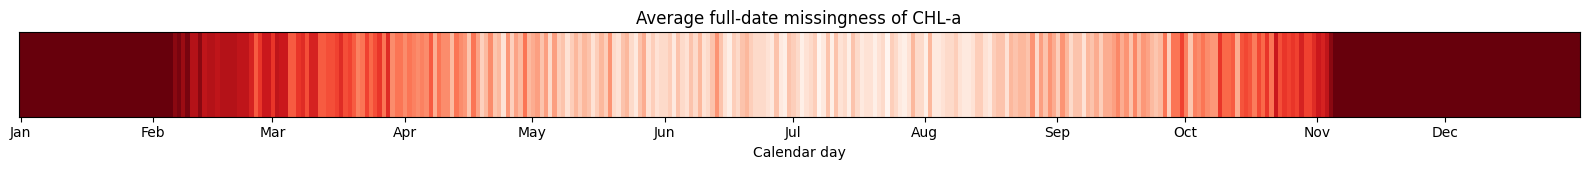

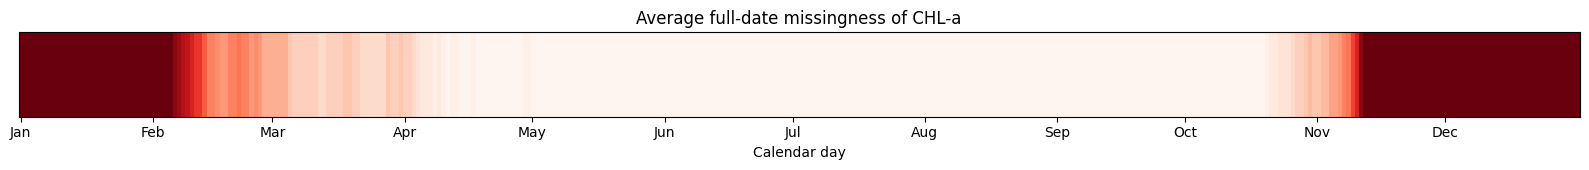

In [11]:
missing = chla_imputed["CHL"].isnull().all(dim=("cell")).values

for cube in [chla, chla_imputed]:
        missing = cube["CHL"].isnull().all(dim=("cell")).values
        yearly = np.full((len(years), 366), np.nan)
        for i, year in enumerate(years):
                d = dates[dates.year == year]
                yearly[i, d.dayofyear - 1] = missing[dates.year == year]

        avg = np.nanmean(yearly, axis=0)

        plt.figure(figsize=(16, 1.8))
        plt.imshow([avg], cmap="Reds", aspect="auto", vmin=0, vmax=1)

        months = pd.date_range("2023-01-01", "2023-12-01", freq="MS")
        plt.xticks(months.dayofyear - 1, months.strftime("%b"))
        plt.yticks([])
        plt.xlabel("Calendar day")
        plt.title("Average full-date missingness of CHL-a")
        plt.tight_layout()
        plt.show()

In [12]:
output_tar = Path("area_1_imputed.tar")

with tempfile.TemporaryDirectory() as tmpdir:
    tmp_zarr = Path(tmpdir) / "area_1_imputed.zarr"
    chla_imputed.to_zarr(tmp_zarr, mode="w", consolidated=True)
    with tarfile.open(output_tar, "w") as tar:
        tar.add(tmp_zarr, arcname=tmp_zarr.name)

c:\Users\janav\Documents\projects\spatio-temporal-xai\.venv\Lib\site-packages\zarr\api\asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


### High chl-a likelihood

C:\Users\janav\AppData\Local\Temp\ipykernel_29884\1125537206.py:8: RuntimeWarning: Mean of empty slice
  threshold = np.nanmean(np.nanmean(vals, axis=1))


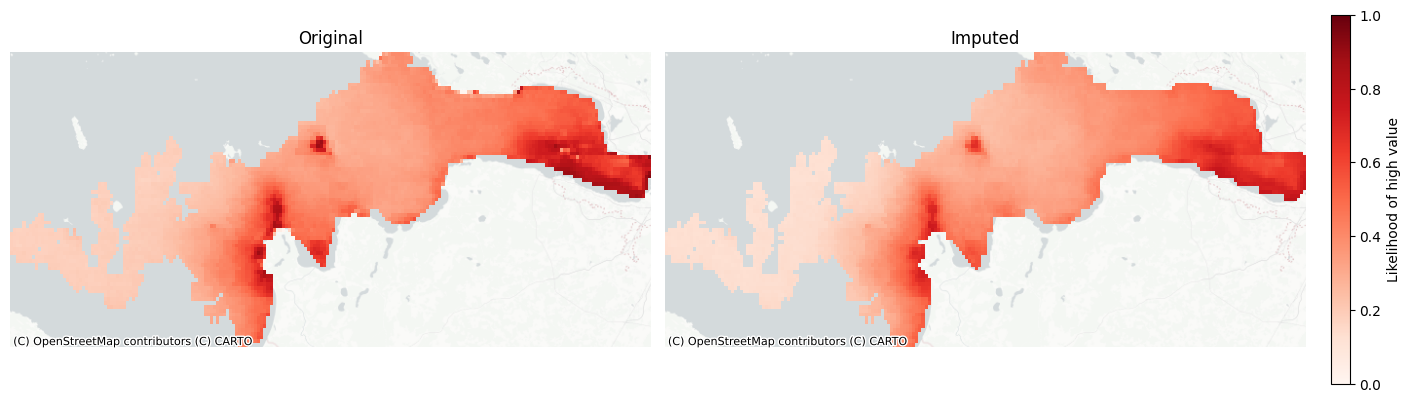

In [13]:
tr = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plots, extents = [], []

for cube in [chla, chla_imputed]:
    vals = cube["CHL"].values
    valid = np.isfinite(vals)
    threshold = np.nanmean(np.nanmean(vals, axis=1))
    likelihood = np.divide((valid & (vals > threshold)).sum(0), valid.sum(0), out=np.full(vals.shape[1], np.nan), where=valid.sum(0) > 0)

    x, y = tr.transform(cube["cell_lon"].values, cube["cell_lat"].values)
    row = cube["local_row_idx"].values.astype(int)
    col = cube["local_col_idx"].values.astype(int)

    z = np.full((row.max() + 1, col.max() + 1), np.nan)
    z[row, col] = likelihood

    m = np.isfinite(x) & np.isfinite(y)
    extents.append([x[m].min(), x[m].max(), y[m].min(), y[m].max()])
    plots.append(z)

xmin = min(e[0] for e in extents)
xmax = max(e[1] for e in extents)
ymin = min(e[2] for e in extents)
ymax = max(e[3] for e in extents)

cmap = plt.cm.Reds.copy()
cmap.set_bad((0, 0, 0, 0))

for ax, z, title in zip(axes, plots, ["Original", "Imputed"]):
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs="EPSG:3857")
    im = ax.imshow(np.ma.masked_invalid(z), extent=[xmin, xmax, ymin, ymax], origin="lower",
                   cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_axis_off()
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.75, pad=0.02, label="Likelihood of high value")
plt.show()

### Low chl-a likelihood

C:\Users\janav\AppData\Local\Temp\ipykernel_29884\1264504837.py:8: RuntimeWarning: Mean of empty slice
  threshold = np.nanmean(np.nanmean(vals, axis=1))


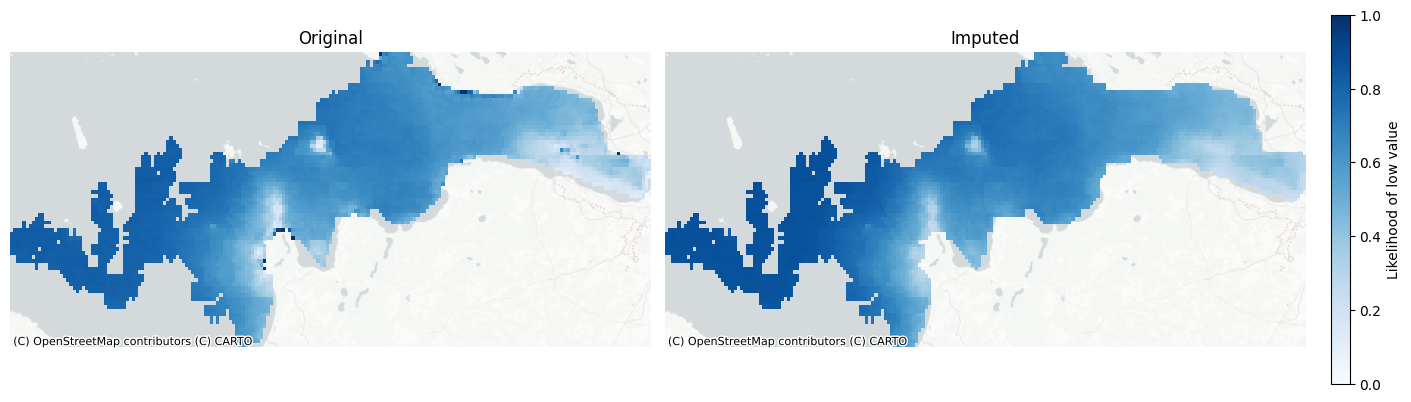

In [14]:
tr = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plots, extents = [], []

for cube in [chla, chla_imputed]:
    vals = cube["CHL"].values
    valid = np.isfinite(vals)
    threshold = np.nanmean(np.nanmean(vals, axis=1))
    likelihood = np.divide((valid & (vals < threshold)).sum(0), valid.sum(0), out=np.full(vals.shape[1], np.nan), where=valid.sum(0) > 0)

    x, y = tr.transform(cube["cell_lon"].values, cube["cell_lat"].values)
    row = cube["local_row_idx"].values.astype(int)
    col = cube["local_col_idx"].values.astype(int)

    z = np.full((row.max() + 1, col.max() + 1), np.nan)
    z[row, col] = likelihood

    m = np.isfinite(x) & np.isfinite(y)
    extents.append([x[m].min(), x[m].max(), y[m].min(), y[m].max()])
    plots.append(z)

xmin = min(e[0] for e in extents)
xmax = max(e[1] for e in extents)
ymin = min(e[2] for e in extents)
ymax = max(e[3] for e in extents)

cmap = plt.cm.Blues.copy()
cmap.set_bad((0, 0, 0, 0))

for ax, z, title in zip(axes, plots, ["Original", "Imputed"]):
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs="EPSG:3857")
    im = ax.imshow(
        np.ma.masked_invalid(z),
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        cmap=cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_axis_off()
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.75, pad=0.02, label="Likelihood of low value")
plt.show()

### Risk raster calculation 

In [15]:
PERSIST_L = 7
SPIKE_W = 15
MAG_STD = 2.0
W_M, W_F, W_P, W_K = 0.35, 0.25, 0.25, 0.15
EPS = 1e-12
Q = 0.90

In [16]:
def compute_region_risk_cell(chl):
    valid = np.isfinite(chl).any("time")

    mu = chl.mean("time", skipna=True)
    sd = chl.std("time", skipna=True)
    M = (mu + MAG_STD * sd).where(valid)

    tau = chl.quantile(Q, dim="time", skipna=True)
    exceed = chl > tau
    F = exceed.mean("time", skipna=True).where(valid)

    run = exceed.rolling(time=PERSIST_L, min_periods=PERSIST_L).sum() == PERSIST_L
    P = run.mean("time", skipna=True).where(valid)

    baseline = chl.rolling(time=SPIKE_W, min_periods=SPIKE_W).mean()
    d = (chl - baseline).where(chl.notnull() & baseline.notnull())
    d = d.where(d > 0, 0.0)
    K = d.mean("time", skipna=True).where(valid)

    def one_sided_z(X):
        mu = X.where(valid).mean(dim="cell", skipna=True)
        sd = X.where(valid).std(dim="cell", skipna=True)
        Z = (X - mu) / (sd + EPS)
        return Z.where(Z > 0, 0.0)

    Mp = one_sided_z(M)
    Fp = one_sided_z(F)
    Pp = one_sided_z(P)
    Kp = one_sided_z(K)

    risk = (W_M * Mp + W_F * Fp + W_P * Pp + W_K * Kp).fillna(0.0)
    return risk

In [17]:
risk_orig = compute_region_risk_cell(chla["CHL"])
risk_imp = compute_region_risk_cell(chla_imputed["CHL"])

c:\Users\janav\Documents\projects\spatio-temporal-xai\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\janav\Documents\projects\spatio-temporal-xai\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


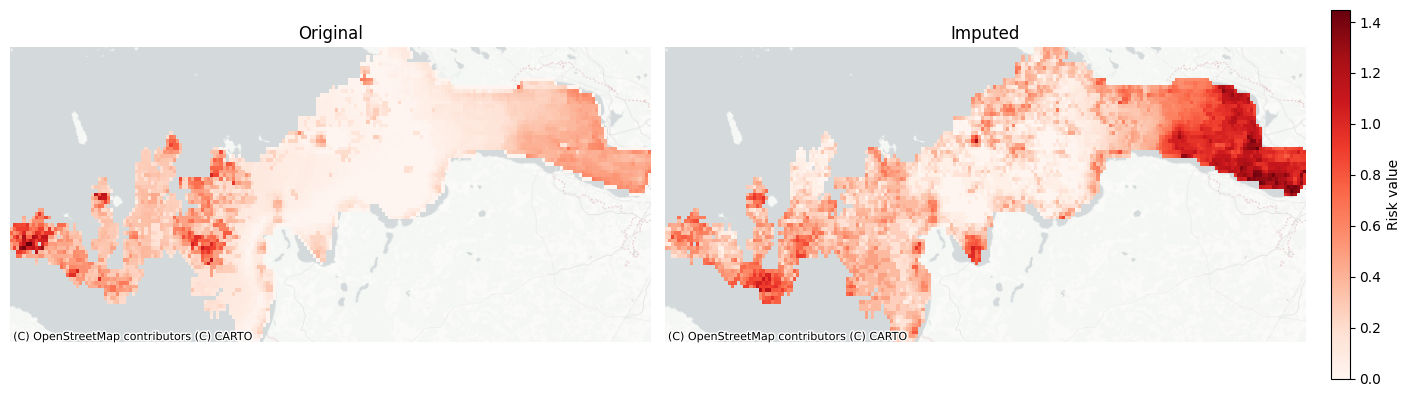

In [18]:
tr = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

x, y = tr.transform(chla["cell_lon"].values, chla["cell_lat"].values)
row = chla["local_row_idx"].values.astype(int)
col = chla["local_col_idx"].values.astype(int)

ny, nx = row.max() + 1, col.max() + 1
z_orig = np.full((ny, nx), np.nan, dtype=float)
z_imp = np.full((ny, nx), np.nan, dtype=float)

z_orig[row, col] = risk_orig.values.astype(float)
z_imp[row, col] = risk_imp.values.astype(float)

m = np.isfinite(x) & np.isfinite(y)
xmin, xmax = x[m].min(), x[m].max()
ymin, ymax = y[m].min(), y[m].max()

cmap = plt.cm.Reds.copy()
cmap.set_bad((0, 0, 0, 0))

for ax, z, title in zip(axes, [z_orig, z_imp], ["Original", "Imputed"]):
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs="EPSG:3857")

    im = ax.imshow(
        np.ma.masked_invalid(z),
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        cmap=cmap,
        interpolation="nearest",
    )

    ax.set_axis_off()
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.75, pad=0.02, label="Risk value")
plt.show()

# Model training

In [31]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from torch.utils.data import DataLoader, TensorDataset

## Data preprocessing

### Sequence building

In [32]:
@dataclass
class SequenceIndex:
    x_start: int
    x_end: int
    y_idx: int


def build_sequences(values_tc, lookback=7):
    valid = np.isfinite(values_tc).all(axis=1)
    seqs = []

    for y_idx in range(lookback, len(valid)):
        if valid[y_idx - lookback : y_idx + 1].all():
            seqs.append(SequenceIndex(y_idx - lookback, y_idx, y_idx))

    return seqs


def sequences_to_tensors(values_tc, seqs, x_scaler, y_scaler):
    x_list, y_list = [], []

    for s in seqs:
        x = values_tc[s.x_start:s.x_end].copy()
        y = np.mean(values_tc[s.y_idx], dtype=np.float32)
        x = x_scaler.transform(x)
        y = y_scaler.transform(np.asarray([y], dtype=np.float32))

        x_list.append(x.astype(np.float32))
        y_list.append(y.astype(np.float32))

    return (
        torch.tensor(np.stack(x_list), dtype=torch.float32),
        torch.tensor(np.stack(y_list), dtype=torch.float32),
    )

### Splitting

In [33]:
def split_by_time(seqs, times, train_ratio=0.7, val_ratio=0.15):
    target_dates = pd.DatetimeIndex([times[s.y_idx] for s in seqs])
    unique_dates = np.array(sorted(target_dates.unique()))

    n = len(unique_dates)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_dates = set(unique_dates[:n_train])
    val_dates = set(unique_dates[n_train:n_train + n_val])
    test_dates = set(unique_dates[n_train + n_val:])

    train, val, test = [], [], []
    for s in seqs:
        d = times[s.y_idx]
        if d in train_dates:
            train.append(s)
        elif d in val_dates:
            val.append(s)
        elif d in test_dates:
            test.append(s)

    return train, val, test

### Scaling

In [34]:
class Standardizer:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, x):
        x = np.asarray(x, dtype=np.float32)
        self.mean_ = float(np.mean(x))
        self.std_ = float(np.std(x))
        if self.std_ == 0:
            self.std_ = 1.0
        return self

    def transform(self, x):
        return (x - self.mean_) / self.std_
    
    def inverse_transform(self, x):
        return x * self.std_ + self.mean_


def fit_scalers(values_tc, train_seqs):
    x_all, y_all = [], []

    for s in train_seqs:
        x = values_tc[s.x_start:s.x_end].copy()
        y = np.mean(values_tc[s.y_idx], dtype=np.float32)

        x_all.append(x.reshape(-1))
        y_all.append(y)

    x_scaler = Standardizer().fit(np.concatenate(x_all))
    y_scaler = Standardizer().fit(np.asarray(y_all, dtype=np.float32))
    return x_scaler, y_scaler

### Data Loaders

In [35]:
def build_loaders(ds, lookback=7, batch_size=32):
    values_tc, times, var_name = ds["CHL"].values.astype(np.float32), pd.to_datetime(ds["time"].values), "CHL"
    seqs = build_sequences(values_tc, lookback=lookback)
    train_seqs, val_seqs, test_seqs = split_by_time(seqs, times)

    x_scaler, y_scaler = fit_scalers(values_tc, train_seqs)

    x_train, y_train = sequences_to_tensors(values_tc, train_seqs, x_scaler, y_scaler)
    x_val, y_val = sequences_to_tensors(values_tc, val_seqs, x_scaler, y_scaler)
    x_test, y_test = sequences_to_tensors(values_tc, test_seqs, x_scaler, y_scaler)

    loaders = {
        "train": DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True),
        "val": DataLoader(TensorDataset(x_val, y_val), batch_size=batch_size, shuffle=False),
        "test": DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False),
    }

    info = {
        "var_name": var_name,
        "n_cells": values_tc.shape[1],
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "times": times,
    }
    return loaders, info

## Model definition

In [36]:
class FrameEncoder(nn.Module):
    def __init__(self, n_cells, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_cells, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class FrameDecoder(nn.Module):
    def __init__(self, latent_dim, n_cells):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, n_cells),
        )

    def forward(self, z):
        return self.net(z)


class AreaRNNAutoencoder(nn.Module):
    def __init__(self, n_cells, latent_dim=64, hidden_dim=128, mlp_dim=64):
        super().__init__()
        self.encoder = FrameEncoder(n_cells, latent_dim)
        self.decoder = FrameDecoder(latent_dim, n_cells)
        self.rnn = nn.GRU(latent_dim, hidden_dim, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, 1),
        )
        self.latent_dim = latent_dim

    def forward(self, x_cube):
        b, l, c = x_cube.shape

        x_flat = x_cube.reshape(b * l, c)
        z_flat = self.encoder(x_flat)
        recon_flat = self.decoder(z_flat)

        z_seq = z_flat.reshape(b, l, self.latent_dim)
        recon_seq = recon_flat.reshape(b, l, c)

        rnn_out, _ = self.rnn(z_seq)
        y_pred = self.head(rnn_out[:, -1, :])

        return {
            "y_pred": y_pred,
            "recon": recon_seq,
        }

## Fit

In [37]:
def train_one_epoch(model, loader, optimizer, device, recon_weight=0.2):
    model.train()
    mse = nn.MSELoss()
    total = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss_forecast = mse(out["y_pred"], y)
        loss_recon = mse(out["recon"], x)
        loss = loss_forecast + recon_weight * loss_recon

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    return total / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    mse = nn.MSELoss()
    total = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        total += mse(out["y_pred"], y).item()

    return total / len(loader)


## Evaluate

In [38]:
@torch.no_grad()
def evaluate_metrics(model, loader, device, y_scaler):
    model.eval()
    y_true_all, y_pred_all = [], []

    for x, y in loader:
        x = x.to(device)
        out = model(x)

        y_true = y.cpu().numpy().ravel()
        y_pred = out["y_pred"].cpu().numpy().ravel()

        y_true = y_scaler.inverse_transform(y_true)
        y_pred = y_scaler.inverse_transform(y_pred)

        y_true_all.append(y_true)
        y_pred_all.append(y_pred)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    mse = np.mean((y_true - y_pred) ** 2)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

    return {"MSE": mse, "MAPE": mape}

## Pipeline

In [39]:
lookback = 7
batch_size = 32
latent_dim = 64
hidden_dim = 128
mlp_dim = 64
epochs = 30
lr = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaders, info = build_loaders(chla_imputed, lookback=lookback, batch_size=batch_size)

model = AreaRNNAutoencoder(
    n_cells=info["n_cells"],
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    mlp_dim=mlp_dim
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_val = float("inf")
best_state = None
history = []

for epoch in tqdm(range(1, epochs + 1), desc="Epochs"):
    train_loss = train_one_epoch(model, loaders["train"], optimizer, device)
    val_loss = evaluate(model, loaders["val"], device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    print(f"epoch={epoch:03d} train={train_loss:.6f} val={val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

Epochs:   3%|▎         | 1/30 [00:01<00:31,  1.10s/it]

epoch=001 train=0.227401 val=0.098340


Epochs:   7%|▋         | 2/30 [00:01<00:26,  1.06it/s]

epoch=002 train=0.161659 val=0.111094


Epochs:  10%|█         | 3/30 [00:02<00:24,  1.11it/s]

...

epoch=028 train=0.063506 val=0.093694


Epochs:  97%|█████████▋| 29/30 [00:24<00:00,  1.17it/s]

epoch=029 train=0.055812 val=0.112507


Epochs: 100%|██████████| 30/30 [00:25<00:00,  1.17it/s]

epoch=030 train=0.053821 val=0.093902


In [41]:
test_loss = evaluate(model, loaders["test"], device)
metrics = evaluate_metrics(
    model,
    loaders["test"],
    device,
    info["y_scaler"],
)

print(f"best_val={best_val:.6f} test_loss={test_loss:.6f}")
print(f"Test MSE:  {metrics['MSE']:.6f}")
print(f"Test MAPE: {metrics['MAPE']:.2f}%")

best_val=0.078122 test_loss=0.077271
Test MSE:  0.762277
Test MAPE: 8.50%


# Spatio-temporal XAI